#### __Tugas 2 Pengenalan Pola: Segmentasi pada Citra Sel Darah__

##### Ahmad Fattah Wardoyo              22/493136/PA/21166
***


import library yang diperlukan meliputi numpy sebagai operasi dasar, matplotlib.pyplot sebagai media penampil citra, dan cv2 sebagai operasi citra.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


input gambar yang ada pada satu folder, pre-processing meliputi pengambilan channel hijau citra (channel hijau merupakan channel terbaik untuk memproses citra medis) dan filter menggunakan median filter.

In [286]:
image = cv2.imread("rbc.jpg")
green_channel = image[:, :, 1]
filter = cv2.medianBlur(green_channel,9)

Proses segmentasi dilakukan melalui thresholding citra dengan metode OTSU dan binary inverse. Hasil yang tidak maksimal akan dilanjutkan dengan Filling hole sehingga hasil dapat membungkus seluruh objek.

In [287]:
_, thresh = cv2.threshold(filter, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Filling hole menggunakan Flood Fill untuk mengisi lubang yang disebabkan oleh cekungan sel darah merah

#Mendapatkan ukuran citra (height, width)
h, w = thresh.shape
print(h, w)

# Mendefinisikan mask yang akan digunakan untuk proses flood fill dengan height & width +2 dari ukuran aslinya
mask = np.zeros((h+2, w+2), np.uint8)

# Mendefinisikan bentuk yang telah didapat dari thresholding sebagai citra yang akan ditumpuk selama proses flood fill
flood_filled = thresh.copy()

# Parameter ketiga merupakan posisi dimulainya flood fill. 
# Posisi ini perlu diletakkan ke background citra. Apabila terletak pada objek, flood fill akan gagal.
# Parameter keempat untuk menunjukkan warna dari flood fill. Biasanya bernilai 255, tapi dapat diubah untuk menunjukkan warna hasil floodfill yang lebih baik
cv2.floodFill(flood_filled, mask, (150, 0), 255)

# Inversi hasilnya agar mendapatkan bentuk penuh sel darah merah
filled_holes = cv2.bitwise_not(flood_filled)

# Menggabungkan hasil filling hole dengan hasil segmentasi awal
final_segmented = cv2.bitwise_or(thresh, filled_holes)

# Morphological Closing untuk memperbaiki batas objek
kernel = np.ones((3,3), np.uint8)
closed = cv2.morphologyEx(final_segmented, cv2.MORPH_CLOSE, kernel, iterations=2)



768 1024


Menampilkan citra tiap proses mulai dari citra asli hingga hasil segmentasi

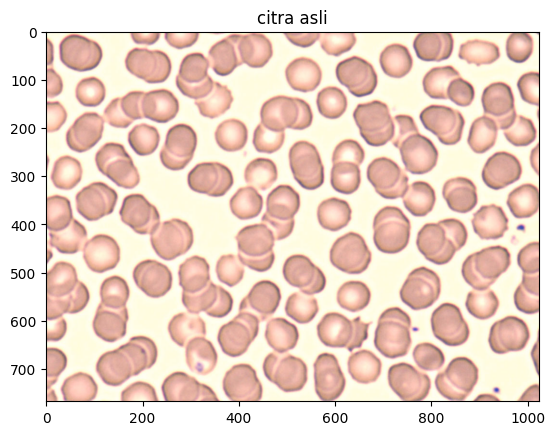

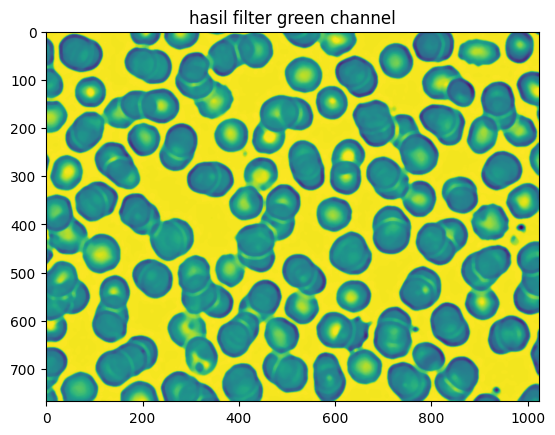

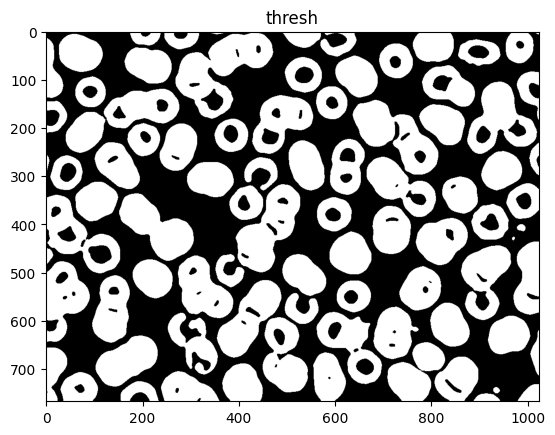

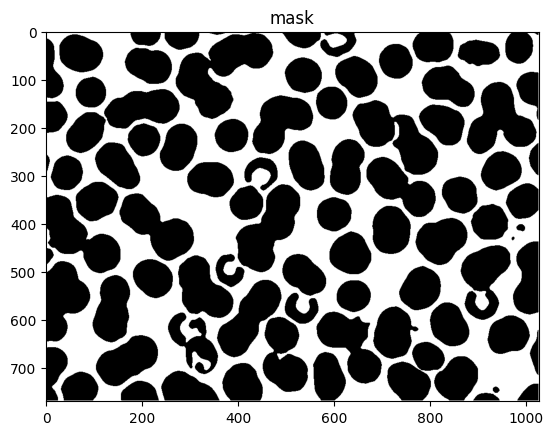

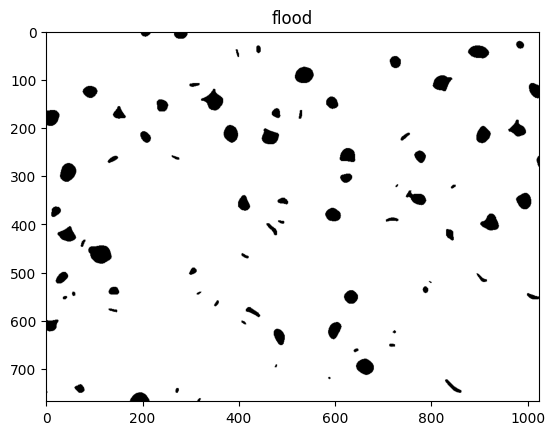

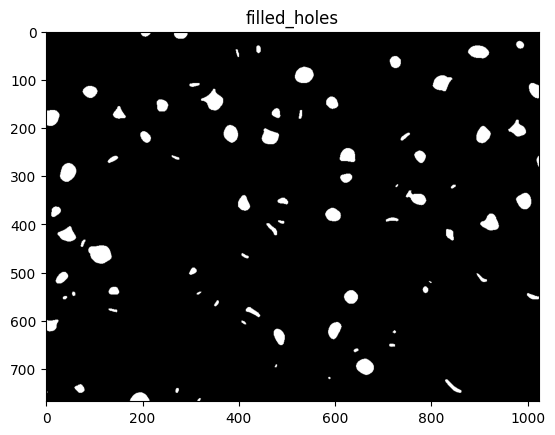

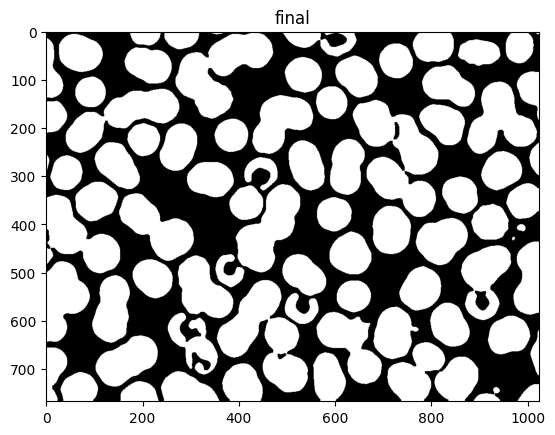

In [288]:
plt.title("citra asli")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

plt.title("hasil filter green channel")
plt.imshow(filter)
plt.show()

plt.title("thresh")
plt.imshow(thresh, cmap="gray")
plt.show()

plt.title("mask")
plt.imshow(mask, cmap="gray")
plt.show()

plt.title("flood")
plt.imshow(flood_filled, cmap="gray")
plt.show()

plt.title("filled_holes")
plt.imshow(filled_holes, cmap="gray")
plt.show()

plt.title("final")
plt.imshow(closed, cmap="gray")
plt.show()
